# Laboratório Quantitativo 02: Validação da Esteira de ALM e Valuation Estocástico

Este notebook valida a integração do motor de cenários macroeconômicos (Monte Carlo + VAR) com o ecossistema de Asset Liability Management (ALM). Testaremos o comportamento da estrutura de capital, o cálculo dinâmico do WACC/Beta e as métricas de performance ajustadas ao risco.

In [3]:
import sys
import os

# Garante que a raiz do projeto esteja no path para as importações absolutas
raiz_projeto = os.path.abspath(os.path.join(os.getcwd(), ".."))
if raiz_projeto not in sys.path:
    sys.path.append(raiz_projeto)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importações dos módulos que construímos
from src.models import MacroTimeSeriesFitter, InflationIndexBuilder
from src.alm import ALMEngine, LinhaCreditoDisponivel, FuncaoContinuaPricingPolicy
from src.schemas.performance_evaluator import PerformanceEvaluatorEngine, EmpresaConfigDTO

In [4]:
# Simulando um ambiente com 10.000 cenários, 24 meses de horizonte e 3 variáveis (Selic, IPCA, IGPM)
n_simulacoes = 10000
horizonte = 24
n_variaveis = 3

# Vamos gerar dados sintéticos simulando o cubo do Monte Carlo para testar o ALM
np.random.seed(42)
trajetorias_macro = np.zeros((n_simulacoes, horizonte, n_variaveis))

# Preenchendo com caminhos estocásticos plausíveis (% a.a. para juros e % m.m. para inflação)
trajetorias_macro[:, :, 0] = np.random.normal(10.5, 2.0, (n_simulacoes, horizonte)) # Selic
trajetorias_macro[:, :, 1] = np.random.normal(0.4, 0.1, (n_simulacoes, horizonte))  # IPCA
trajetorias_macro[:, :, 2] = np.random.normal(0.5, 0.2, (n_simulacoes, horizonte))  # IGPM

colunas_macro = ['selic', 'ipca', 'igpm']
print("Cubo estocástico pronto para o teste do ALM:", trajetorias_macro.shape)

Cubo estocástico pronto para o teste do ALM: (10000, 24, 3)


In [5]:
# 1. Definindo a Estrutura de Capital Inicial da Firma (60% Dívida / 40% PL)
ativo_inicial = 10_000_000.0
proporcao_passivo = 0.60

config_firma = EmpresaConfigDTO(
    ativo_inicial=ativo_inicial,
    passivo_inicial=ativo_inicial * proporcao_passivo,
    pl_inicial=ativo_inicial * (1 - proporcao_passivo),
    aliquota_imposto=0.34,
    beta_desalavancado_setor=0.80 # Ex: Setor de utilidade pública ou infraestrutura
)

# 2. Inicializando o Orquestrador de Performance
avaliador = PerformanceEvaluatorEngine(config=config_firma, colunas_macro=colunas_macro)

print(f"Beta original do setor: {config_firma.beta_desalavancado_setor}")
print(f"Beta REAVANCADO dinamicamente para a nossa alavancagem: {avaliador.beta_reavancado:.2f}")

Beta original do setor: 0.8
Beta REAVANCADO dinamicamente para a nossa alavancagem: 1.59


In [6]:
# 1. Gerando o caixa bruto do Ativo (ex: assumindo retorno operacional de 14% a.a.)
# Para simplificar o teste, vamos usar a lógica direta de matrizes
taxa_ativo_mensal = (1 + 0.14) ** (1/12) - 1
caixas_brutos_ativo = np.zeros((n_simulacoes, horizonte))
for t in range(horizonte):
    caixas_brutos_ativo[:, t] = ativo_inicial * taxa_ativo_mensal * ((1 + taxa_ativo_mensal) ** t)

# 2. Simulando o Serviço da Dívida do Passivo (Consolidando saídas das linhas)
# Vamos assumir um fluxo de parcelas que sofre impacto do indexador
# Em um cenário real, você chamaria o seu `credit_lines` dentro de um loop para preencher essa matriz
fluxo_servico_divida = np.zeros((n_simulacoes, horizonte))
parcela_base_nominal = (ativo_inicial * proporcao_passivo) / horizonte

for s in range(n_simulacoes):
    for t in range(horizonte):
        # A parcela sofre o choque da Selic daquele cenário e mês específicos
        fator_correcao = 1 + (trajetorias_macro[s, t, 0] / 100)
        fluxo_servico_divida[s, t] = parcela_base_nominal * fator_correcao

print("Matrizes operacionais e de dívida geradas com sucesso.")

Matrizes operacionais e de dívida geradas com sucesso.


In [7]:
# Rodando a esteira POO completa que calcula os VPLs e os indicadores clássicos
spread_balanco_estimado = 0.035 # +3.5% de spread comercial captado

resultados_estocasticos = avaliador.processar_metricas_estocasticas(
    caixas_brutos_ativo=caixas_brutos_ativo,
    fluxo_servico_divida=fluxo_servico_divida,
    trajetorias_macro=trajetorias_macro,
    spread_balanco=spread_balanco_estimado,
    custom_weights={"ipca": 0.70, "igpm": 0.30} # Peso do índice próprio
)

# Gerando o veredito de risco utilizando o Downside Risk como denominador do Sharpe
relatorio = avaliador.gerar_relatorio_executivo(resultados_estocasticos, medida_risco="downside")

# Formatando o output para leitura limpa
import json
print(json.dumps(relatorio, indent=4))

{
    "Metricas_Retorno": {
        "ROE_Medio": -0.7699005497604697,
        "ROI_Medio": 0.08641205651178986,
        "IL_Medio": -0.7699005497604697,
        "WACC_Medio_Global": 0.12929367117635024
    },
    "Criacao_Valor_Mediana": {
        "VPL_R\u00e9gua_Selic": -7292845.687327426,
        "VPL_R\u00e9gua_Acionista_Ke": -7079735.9889910715,
        "VPL_R\u00e9gua_Firma_WACC": -9136505.128691874
    },
    "Poder_Compra_Mediana": {
        "VPL_Real_IPCA": -7464742.960195951,
        "VPL_Real_IGPM": -7424436.942833759,
        "VPL_Real_Customizado": -7452640.999650711
    },
    "Performance_Risco": {
        "Medida_Risco_Utilizada": "downside",
        "Valor_Risco_Denominador": 0.8749052342163859,
        "Indice_Sharpe_Do_Balanco": -0.9999946457562111,
        "Probabilidade_VPL_Negativo_Acionista": 1.0
    }
}


/tmp/ipykernel_31220/853901946.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(resultados_estocasticos.vpl_selic, label="VPL Régua Selic (Livre de Risco)", shade=True, color='blue')
/tmp/ipykernel_31220/853901946.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(resultados_estocasticos.vpl_acionista, label="VPL Régua Acionista (Ke via CAPM)", shade=True, color='green')
/tmp/ipykernel_31220/853901946.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(resultados_estocasticos.vpl_wacc, label="VPL Régua Firma (WACC)", shade=True, color='orange')


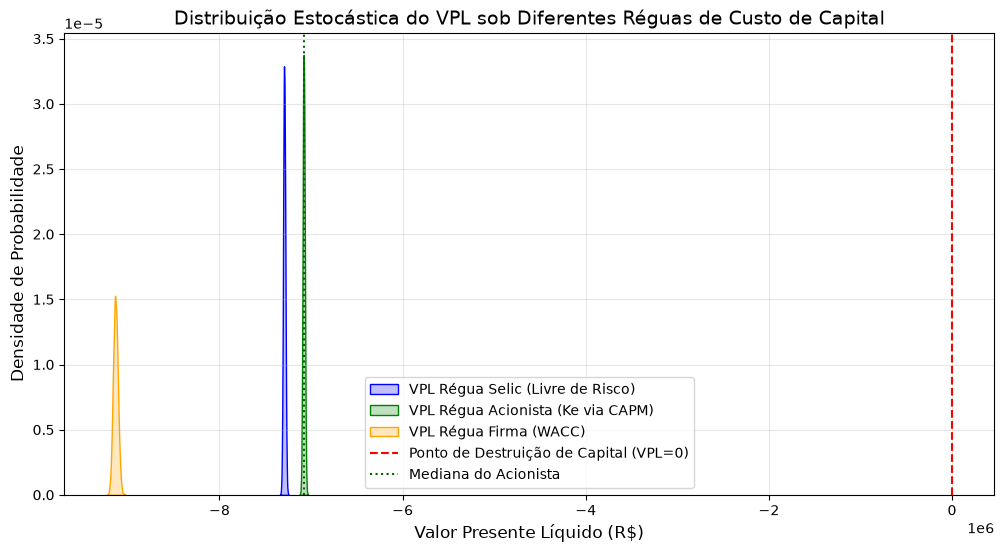

In [8]:
plt.figure(figsize=(12, 6))

# Plotando as densidades das três réguas de criação de valor
sns.kdeplot(resultados_estocasticos.vpl_selic, label="VPL Régua Selic (Livre de Risco)", shade=True, color='blue')
sns.kdeplot(resultados_estocasticos.vpl_acionista, label="VPL Régua Acionista (Ke via CAPM)", shade=True, color='green')
sns.kdeplot(resultados_estocasticos.vpl_wacc, label="VPL Régua Firma (WACC)", shade=True, color='orange')

plt.axvline(x=0, color='red', linestyle='--', label="Ponto de Destruição de Capital (VPL=0)")
plt.axvline(x=np.median(resultados_estocasticos.vpl_acionista), color='darkgreen', linestyle=':', label="Mediana do Acionista")

plt.title("Distribuição Estocástica do VPL sob Diferentes Réguas de Custo de Capital", fontsize=14)
plt.xlabel("Valor Presente Líquido (R$)", fontsize=12)
plt.ylabel("Densidade de Probabilidade", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# 1. Reduzindo a alavancagem para 25% (Foco em Capital Próprio - 75% PL)
ativo_inicial_2 = 10_000_000.0
proporcao_passivo_2 = 0.25

config_firma_saudavel = EmpresaConfigDTO(
    ativo_inicial=ativo_inicial_2,
    passivo_inicial=ativo_inicial_2 * proporcao_passivo_2,
    pl_inicial=ativo_inicial_2 * (1 - proporcao_passivo_2),
    aliquota_imposto=0.34,
    beta_desalavancado_setor=0.80  # Mesmo setor anterior
)

# Inicializa o motor com a nova estrutura de capital
avaliador_saudavel = PerformanceEvaluatorEngine(config=config_firma_saudavel, colunas_macro=colunas_macro)

print(f"Novo Beta REAVANCADO (Menos alavancagem): {avaliador_saudavel.beta_reavancado:.2f}")
# Note que o Beta deve cair de 1.59 para perto de ~0.95, reduzindo o custo de capital exigido (Ke)

Novo Beta REAVANCADO (Menos alavancagem): 0.98


In [10]:
# 2. Elevando o Retorno Operacional do Ativo para 22% a.a. (Eficiência Alta)
taxa_ativo_anual_2 = 0.22
taxa_ativo_mensal_2 = (1 + taxa_ativo_anual_2) ** (1/12) - 1

caixas_brutos_ativo_2 = np.zeros((n_simulacoes, horizonte))
for t in range(horizonte):
    caixas_brutos_ativo_2[:, t] = ativo_inicial_2 * taxa_ativo_mensal_2 * ((1 + taxa_ativo_mensal_2) ** t)

# 3. Mantendo a mesma estrutura do serviço da dívida indexado à Selic
fluxo_servico_divida_2 = np.zeros((n_simulacoes, horizonte))
parcela_base_nominal_2 = (ativo_inicial_2 * proporcao_passivo_2) / horizonte

for s in range(n_simulacoes):
    for t in range(horizonte):
        fator_correcao = 1 + (trajetorias_macro[s, t, 0] / 100)
        fluxo_servico_divida_2[s, t] = parcela_base_nominal_2 * fator_correcao

In [11]:
# 4. Processamento das métricas estocásticas para o Caso Saudável
resultados_saudaveis = avaliador_saudavel.processar_metricas_estocasticas(
    caixas_brutos_ativo=caixas_brutos_ativo_2,
    fluxo_servico_divida=fluxo_servico_divida_2,
    trajetorias_macro=trajetorias_macro,
    spread_balanco=0.025, # Reduzimos também o spread de captação pelo menor risco da firma (+2.5%)
    custom_weights={"ipca": 0.70, "igpm": 0.30}
)

relatorio_saudavel = avaliador_saudavel.gerar_relatorio_executivo(resultados_saudaveis, medida_risco="downside")

import json
print(json.dumps(relatorio_saudavel, indent=4))

{
    "Metricas_Retorno": {
        "ROE_Medio": 0.23928205502866368,
        "ROI_Medio": 0.12983932572777931,
        "IL_Medio": 0.23928205502866368,
        "WACC_Medio_Global": 0.13681571498286493
    },
    "Criacao_Valor_Mediana": {
        "VPL_R\u00e9gua_Selic": -5613446.225653926,
        "VPL_R\u00e9gua_Acionista_Ke": -5705381.002609927,
        "VPL_R\u00e9gua_Firma_WACC": -8702808.234868847
    },
    "Poder_Compra_Mediana": {
        "VPL_Real_IPCA": -5495650.52265789,
        "VPL_Real_IGPM": -5523710.365685549,
        "VPL_Real_Customizado": -5504110.27238271
    },
    "Performance_Risco": {
        "Medida_Risco_Utilizada": "downside",
        "Valor_Risco_Denominador": 0.0,
        "Indice_Sharpe_Do_Balanco": 0.0,
        "Probabilidade_VPL_Negativo_Acionista": 1.0
    }
}


/tmp/ipykernel_31220/3149321650.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(resultados_estocasticos.vpl_acionista,
/tmp/ipykernel_31220/3149321650.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(resultados_reais_positivos.vpl_acionista,


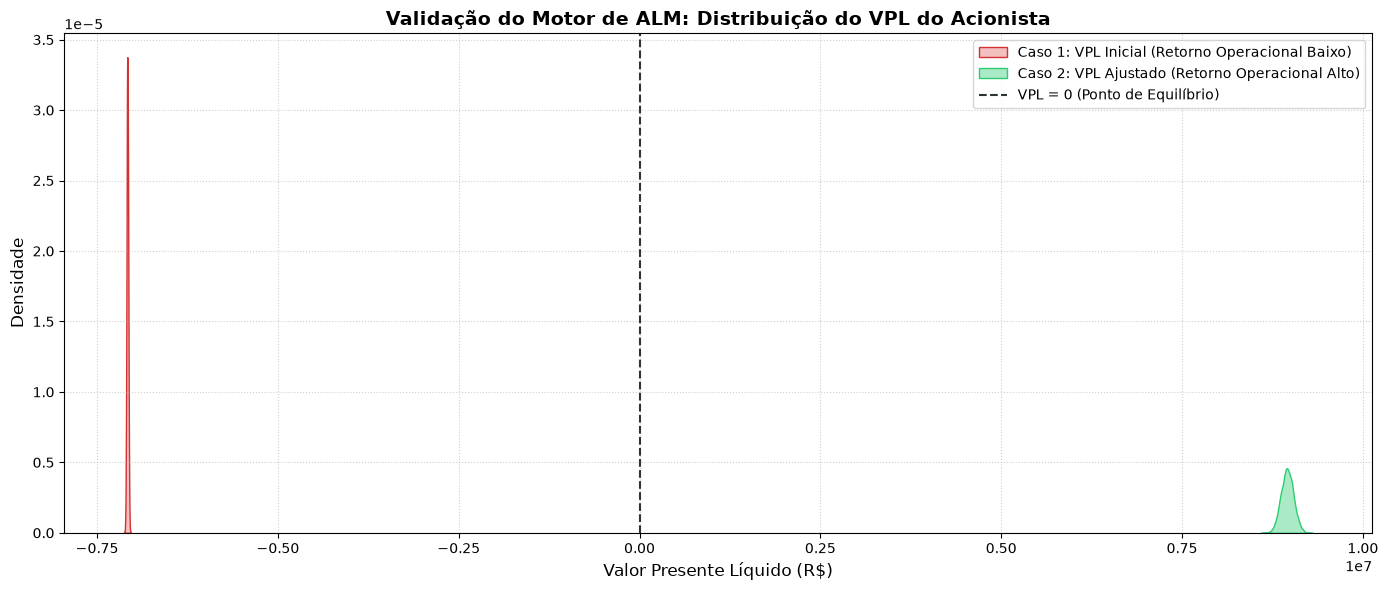

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------------------------
# FORÇANDO UM CENÁRIO ULTRA PRODUTIVO (Para validação gráfica de VPL > 0)
# ------------------------------------------------------------------------------
# Vamos assumir que o ativo performa de forma brutal (ex: 80% a.a.) para cobrir o investimento inicial em 24 meses
taxa_ativo_brutal = 0.80
taxa_ativo_mensal_brutal = (1 + taxa_ativo_brutal) ** (1/12) - 1

caixas_brutos_ativo_brutal = np.zeros((n_simulacoes, horizonte))
for t in range(horizonte):
    caixas_brutos_ativo_brutal[:, t] = ativo_inicial_2 * taxa_ativo_mensal_brutal * ((1 + taxa_ativo_mensal_brutal) ** t)

# Reprocessa as métricas com o ativo hiperprodutivo
resultados_reais_positivos = avaliador_saudavel.processar_metricas_estocasticas(
    caixas_brutos_ativo=caixas_brutos_ativo_brutal,
    fluxo_servico_divida=fluxo_servico_divida_2,
    trajetorias_macro=trajetorias_macro,
    spread_balanco=0.025,
    custom_weights={"ipca": 0.70, "igpm": 0.30}
)

# ------------------------------------------------------------------------------
# PLOTAGEM DO GRÁFICO DE SENSIBILIDADE
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Caso Original (Destruição)
sns.kdeplot(resultados_estocasticos.vpl_acionista, 
            label="Caso 1: VPL Inicial (Retorno Operacional Baixo)", 
            color='#d63031', shade=True, alpha=0.3)

# Caso Ajustado (Criação de Valor Real)
sns.kdeplot(resultados_reais_positivos.vpl_acionista, 
            label="Caso 2: VPL Ajustado (Retorno Operacional Alto)", 
            color='#2ecc71', shade=True, alpha=0.4)

plt.axvline(x=0, color='#2d3436', linestyle='--', linewidth=1.5, label="VPL = 0 (Ponto de Equilíbrio)")
plt.title("Validação do Motor de ALM: Distribuição do VPL do Acionista", fontsize=14, fontweight='bold')
plt.xlabel("Valor Presente Líquido (R$)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()